# Atom Tracing - Python Version

Based on UCLA files in Atom tracing, which in turn was based on R.Xu, UCLA, 2014.

Cited as by: 
Y. Yang, C.-C. Chen, M. C. Scott, C. Ophus, R. Xu, A. Pryor Jr., L. Wu, F. Sun, W. Theis, J. Zhou, M. Eisenbach, P. R. C. Kent, R. F. Sabirianov, H. Zeng, P. Ercius and J. Miao, “Deciphering chemical order/disorder and material properties at the single-atom level”, Nature 542, 75-79 (2017). https://dx.doi.org/10.1038/nature21042

Translated by E.Kitching 2025-2026

In [1]:
import scipy
import numpy as np
import skimage.io as skimage
import cupy
import matplotlib.pyplot as plt
%matplotlib widget
# check that the required imports are working

In [2]:
import AtomTracing as atom_tracing

## Example use of code

In [3]:
#loading data 
# Simulations known to have 231 Ce atoms, and 671 O.

# original version used .mat but can use .mrc or .tif
vol = skimage.imread(r"iDPC_ideal_all_angles_EM20i_bin2.tif")
# zero pad the reconstructed volume
pad_width = ((10, 10), (10, 10), (10, 10))
DataMatrix = np.pad(vol, pad_width, mode='constant', constant_values=0)

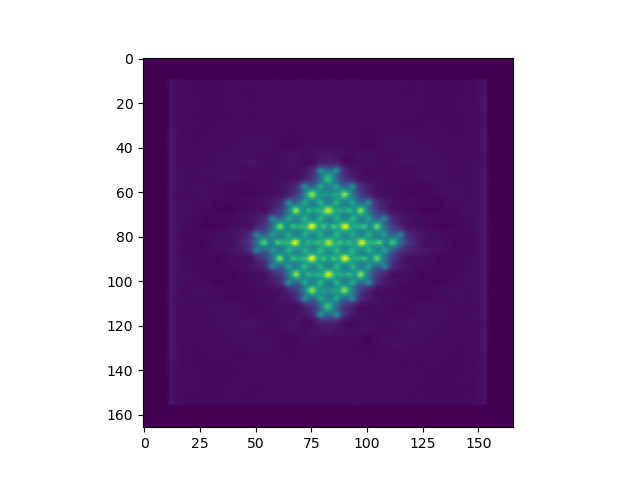

In [4]:
plt.figure()
plt.imshow(DataMatrix[100])
plt.show()

In [5]:
object_mask= atom_tracing.extract_clean_3d_object(DataMatrix, 2000)

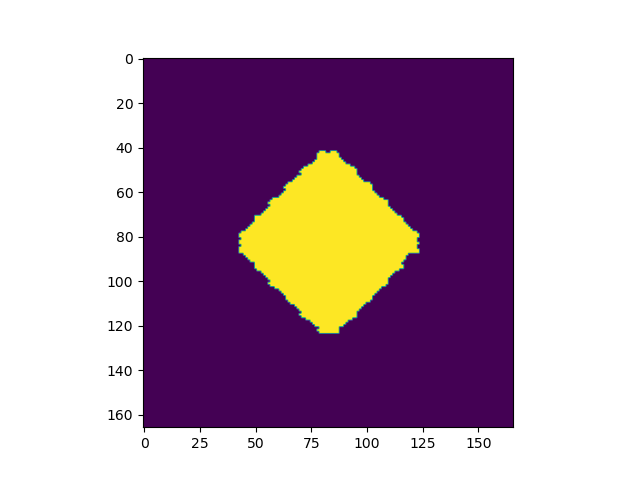

In [6]:
plt.figure()
plt.imshow(object_mask[100])
plt.show()

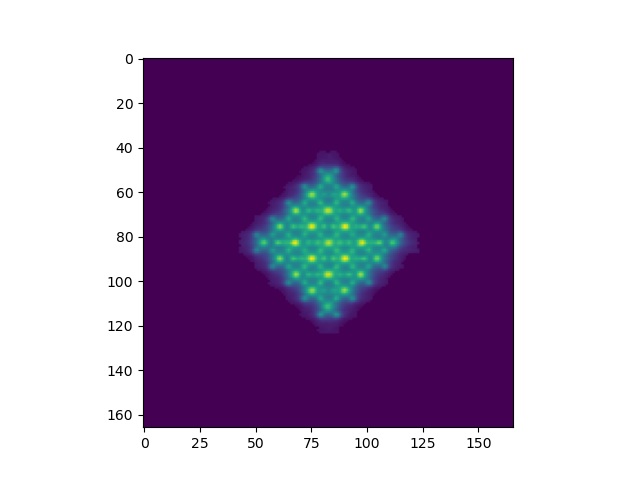

In [7]:
#supp = read(r'C:/path/to/support')   #  loose binary support. mask to add valid atom, if not made above
DataMatrix = DataMatrix * object_mask 

#init variables, must be odd. pixel size in example data is 0.3816
Maxima_box = 3 #pixel box size used to find maxima. 1 to skip it in case of overlapping maxima i.e. Ce overshadowing O
OffCent_box = 5 #pixel box size used box for fitting off-center gauss
MaxNumberPeaks = 950 #max peaks to find, can use approximation from known number of atoms from simulations
MinPixelDist = 5 #in pixels, min distance, 9 corresponds to 3.43A so good for Ce-Ce. 6*0.3816 = 2.28,good for Ce-O
Dmin_presort = 4 # distance to blanket reject pixels prior to sub-pixel maxima fit. I prefer 2 pixels lower than min dist.
# prefix for output file
outputstring = 'iDPC_Simulations'

plt.figure()
plt.imshow(DataMatrix[100])
plt.show()

In [8]:
#coords in Z, Y, X - you can check that the plot matches raw from above
# for the sims, the positions are known
coords_check = [
    (120, 75, 83),   # ce atom pos
    (40, 83, 83),    # Ce atom pos at edge
    (43, 86, 72),   # o atom pos 
    (58, 79, 58),   # o atom near edge
    (115, 50, 50),   # background
]

for x, y, z in coords_check:
    neighbourhood_sum = np.sum(DataMatrix[x-1:x+2, y-1:y+2, z-1:z+2])
    print(f"3x3x3 sum at ({x},{y},{z}): {neighbourhood_sum:.2f}")
    print(f"Raw voxel intensity: {DataMatrix[x, y, z]:.2f}")

# Th is from 3x3x3 sum, be conservative if need be! 
# In this case, the mask is good so threshold can be small.
Th= 1000

3x3x3 sum at (120,75,83): 425409.00
Raw voxel intensity: 21949.00
3x3x3 sum at (40,83,83): 453666.00
Raw voxel intensity: 29369.00
3x3x3 sum at (43,86,72): 93997.00
Raw voxel intensity: 4882.00
3x3x3 sum at (58,79,58): 123023.00
Raw voxel intensity: 6361.00
3x3x3 sum at (115,50,50): 0.00
Raw voxel intensity: 0.00


In [ ]:
# find possible atoms (minimal distance constraint applied)
# atom_pos is the xyz positions (in the unit of pixel) of found local maxima peaks
# close_pos is the xyz positions of peaks which violate the minimum distance constraint
# statsI is the initial Gaussian fitting parameters of each peak
# statsF is the final Gaussian fitting parameters of each peak
# fit options are the curve_fit wrapper or lsq directly

atom_pos, close_pos, statsI, statsF = atom_tracing.find_possible_atoms(DataMatrix,  MinPixelDist, Dmin_presort, MaxNumberPeaks, Maxima_box, OffCent_box, Th, fit_method='lsq', use_gpu=True, stats=True, presort=True, parallel_statsF=True)

Peaks above threshold: 902 / 4242915 total maxima
Atom number:0232 	 Prescreened: candidate (90, 84, 90) too close to accepted atom at (90.13, 82.54, 89.90) (distance=1.474 voxels < Dmin_presort=4 voxels)
Atom number:0232 	 Prescreened: candidate (76, 84, 90) too close to accepted atom at (75.88, 82.63, 89.82) (distance=1.387 voxels < Dmin_presort=4 voxels)
Atom number:0232 	 Prescreened: candidate (76, 84, 76) too close to accepted atom at (75.94, 82.56, 75.78) (distance=1.462 voxels < Dmin_presort=4 voxels)
Atom number:0232 	 Prescreened: candidate (83, 84, 83) too close to accepted atom at (83.00, 82.37, 82.90) (distance=1.629 voxels < Dmin_presort=4 voxels)


In [ ]:
mask = ~(np.all(atom_pos == 0, axis=0))
atom_pos_clean = atom_pos[:, mask]

In [ ]:
print(len(atom_pos_clean.T))

In [ ]:
# save result
DataName = 'Test_Unified_onSims_th1000_iDPC_3_5'
TracingStep = 'Dmin_5pix_' 
np.savez('{}_{}_step{}.npz'.format(DataName, outputstring, TracingStep), atom_pos=atom_pos_clean, close_pos=close_pos, Dmin_presort=Dmin_presort, Dmin=MinPixelDist, statsF=statsF, statsI=statsI, DataMatrix=DataMatrix, MaxNumberPeaks=MaxNumberPeaks)

## Plot outputs

In [ ]:
def plot_central_slices(DataMatrix, atom_pos, tol=3):
    accepted = atom_pos[:, :]
    ax_x, ax_y, ax_z = accepted[0], accepted[1], accepted[2]
    
    cx = DataMatrix.shape[0] // 2
    cy = DataMatrix.shape[1] // 2
    cz = DataMatrix.shape[2] // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # YZ
    axes[0].imshow(DataMatrix[cx, :, :], origin='lower', cmap='gray')
    mask = np.abs(ax_x - cx) <= tol
    axes[0].scatter(ax_z[mask], ax_y[mask], s=10, c='red', alpha=0.7)
    axes[0].set_title(f'YZ plane (X={cx})')
    axes[0].set_xlabel('Z'); axes[0].set_ylabel('Y')

    # XZ
    axes[1].imshow(DataMatrix[:, cy, :], origin='lower', cmap='gray')
    mask = np.abs(ax_y - cy) <= tol
    axes[1].scatter(ax_z[mask], ax_x[mask], s=10, c='red', alpha=0.7)
    axes[1].set_title(f'XZ plane (Y={cy})')
    axes[1].set_xlabel('Z'); axes[1].set_ylabel('X')

    # XY
    axes[2].imshow(DataMatrix[:, :, cz], origin='lower', cmap='gray')
    mask = np.abs(ax_z - cz) <= tol
    axes[2].scatter(ax_y[mask], ax_x[mask], s=10, c='red', alpha=0.7)
    axes[2].set_title(f'XY plane (Z={cz})')
    axes[2].set_xlabel('Y'); axes[2].set_ylabel('X')

    plt.tight_layout()
    plt.show()

def plot_atom_3d(atom_pos):
    accepted = atom_pos[:, :]
    fig = plt.figure(figsize=(8, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(accepted[2], accepted[1], accepted[0], s=5, alpha=0.5, c='red')
    ax.set_xlabel('Z'); ax.set_ylabel('Y'); ax.set_zlabel('X')
    ax.set_title('Accepted atom positions')
    plt.tight_layout()
    plt.show()

plot_atom_3d(atom_pos_clean)
plot_central_slices(DataMatrix, atom_pos, tol=3)

# this shows the vast majority of atoms are detected! any missing or misassigned atoms can be manually adjusted afterwards.